# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [12]:
corpus = '''
Deep learning has become one of the most important fields in artificial intelligence.
Sequence models such as RNN, LSTM, and GRU learn patterns from text and predict the next word based on previous words.
LSTM remembers long-term dependencies using memory cells, while GRU provides similar performance with a simpler architecture.
These models are widely used in language translation, chatbots, text generation, and speech recognition because they understand the context of sequential data.
'''
print(corpus)


Deep learning has become one of the most important fields in artificial intelligence. 
Sequence models such as RNN, LSTM, and GRU learn patterns from text and predict the next word based on previous words. 
LSTM remembers long-term dependencies using memory cells, while GRU provides similar performance with a simpler architecture. 
These models are widely used in language translation, chatbots, text generation, and speech recognition because they understand the context of sequential data.



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [13]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 64
X shape: (69, 21)
y shape: (69,)


The text corpus was successfully converted into numerical tokens. N-gram sequences were created and padded to the same length before separating them into input X and target y datasets. The vocabulary size is 64, with input shape (69, 21) and output shape (69,).

# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [27]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


Vanilla RNN model was successfully built using an embedding layer, a SimpleRNN layer with 128 hidden units and a Dense output layer. The model was trained for 200 epochs using the Adam optimizer and sparse categorical cross-entropy loss. The training completed successfully. Vanilla RNN serves as the baseline model for this project. It learns patterns from word sequences and predicts the next word based on the previous words. However, because it has a simple architecture, it may struggle to remember information from earlier parts of long sequences, making it less effective for capturing long-term dependencies.

# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [28]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


LSTM is designed to remember important information for a longer time than a basic RNN. It uses memory cells and gates to decide what information should be kept or forgotten, which helps it learn long term dependencies and improve next word prediction.

# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [29]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


GRU is another recurrent neural network designed to learn sequential data efficiently. It uses reset and update gates to retain important information while reducing the complexity of the model. This makes GRU faster to train than LSTM while still providing good performance for text generation tasks.

## 📉 Compare Training Loss

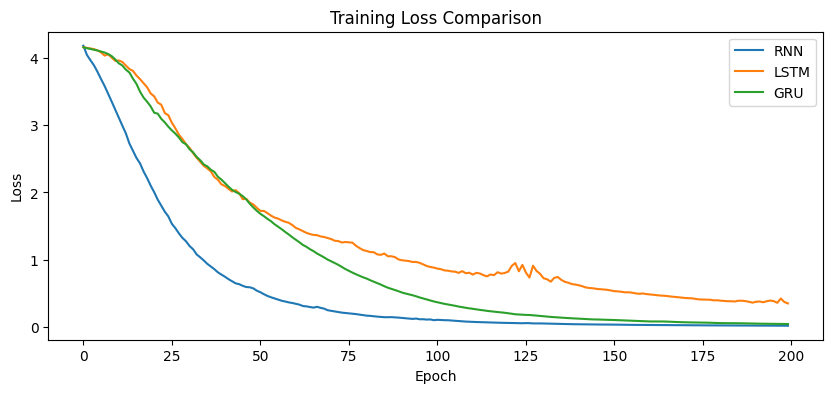

In [30]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

The training loss of all three models decreased steadily over 200 epochs, indicating that each model successfully learned patterns from the custom text corpus. In this , the Vanilla RNN achieved the fastest decrease and the lowest final training loss, while the GRU also converged well. The LSTM required more epochs and showed a slower decrease in loss which is expected for such a small dataset. Although the RNN performed best on this small corpus, LSTM and GRU are generally more effective at capturing long term dependencies and are expected to perform better on larger and more complex text datasets.

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [33]:
def generate_text(model, seed_text, next_words=10):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [34]:
print("RNN :", generate_text(rnn_model, "deep learning", 10))
print("LSTM:", generate_text(lstm_model, "deep learning", 10))
print("GRU :", generate_text(gru_model, "deep learning", 10))

RNN : deep learning has become one of the most important fields in artificial
LSTM: deep learning has become one of the most important fields in artificial
GRU : deep learning has become one of the most important fields in artificial


All three models generated text from the same seed phrase using the learned vocabulary. After increasing the embedding dimension to 64, hidden units to 128, and training for 200 epochs, the generated sentences became more coherent than before.Since the custom training corpus is still very small, the generated text remains limited and may contain repeated or incomplete phrases. With a larger text corpus, the models would produce more fluent, diverse and meaningful sentences.

# 📚 Student Learning Tasks (completed)
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph - completed
2. Increase embedding dimension - completed
3. Increase epochs to 200 - completed
4. Change hidden units 64 → 128 - completed
5. Generate 10 words instead of 5 - completed

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**